In [1]:
%cd ..

import sys
import os

from driverEngine import driverEngine
from utils.data_utils import load_config
import matplotlib.pyplot as plt
import numpy as np
from utils.caption_utils import parse_string
import cv2
import matplotlib.pyplot as plt

/home/ximeng/anaconda3/envs/dllm/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ximeng/Documents/NaviDrive


In [2]:
def plot_six_views_by_token(nusc, token):
    """
    Given a sample token, retrieves and plots the 6 original camera images 
    from the nuScenes dataset individually using matplotlib.
    """
    # 1. Retrieve the sample record using the provided token
    sample_rec = nusc.get('sample', token)
    
    # 2. Define the standard 6 camera channels in nuScenes
    camera_channels = [
        'CAM_FRONT', 
        'CAM_FRONT_RIGHT', 
        'CAM_FRONT_LEFT', 
        'CAM_BACK', 
        'CAM_BACK_LEFT', 
        'CAM_BACK_RIGHT'
    ]
    
    print(f"--- Processing Token: {token} ---")
    
    # 3. Iterate through each camera channel
    for channel in camera_channels:
        # Get the sample_data token for the specific camera
        sd_token = sample_rec['data'][channel]
        sd_rec = nusc.get('sample_data', sd_token)
        
        # Construct the absolute path to the image file
        # nusc.dataroot is the base directory of your dataset
        img_path = os.path.join(nusc.dataroot, sd_rec['filename'])
        
        # 4. Read and display the image
        if os.path.exists(img_path):
            # OpenCV reads in BGR format; convert to RGB for correct matplotlib display
            img_bgr = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            # Create a new figure for each image to print them separately
            plt.figure(figsize=(12, 7))
            plt.imshow(img_rgb)
            
            # Add title with channel name and relative file path
            # plt.title(f"Sensor: {channel}\nFile: {sd_rec['filename']}", fontsize=12)
            
            # Remove axis ticks for a cleaner look
            plt.axis('off')
            
            # Render the plot immediately
            plt.show()
        else:
            print(f"Warning: Image file not found at {img_path}")

In [3]:
def plot_debug_results(pred_outputs, gt_wp_raw, command="Unknown"):
    """
    Plots multiple trajectory candidates against the ground truth, 
    calculates ADE for each, and returns the best performing trajectory.
    """
    plt.figure(figsize=(11, 8))
    
    # 1. Parse Ground Truth trajectory
    gt_pts = parse_string(gt_wp_raw)
    gt_x = gt_pts[:, 0]
    gt_y = gt_pts[:, 1]
    
    # Plot Ground Truth as a thick black line with diamond markers
    plt.plot(gt_x, gt_y, color='black', marker='D', markersize=6, 
             linewidth=3, label='Ground Truth', zorder=10)

    # Define distinct colors for up to 6 candidate trajectories
    colors = ['#FF0000', '#00FF00', '#0000FF', '#FF00FF', '#00FFFF', '#FFA500']
    
    ade_list = []
    parsed_trajectories = [] # List to store numpy arrays of parsed candidates

    # 2. Iterate through each predicted candidate string
    for i, raw_str in enumerate(pred_outputs):
        try:
            # Convert string output to numpy array [N, 2]
            pred_pts = parse_string(raw_str)
            parsed_trajectories.append(pred_pts) # Store for later retrieval
            
            px = pred_pts[:, 0]
            py = pred_pts[:, 1]
            
            # Align lengths to calculate error (Euclidean distance)
            min_len = min(len(gt_pts), len(pred_pts))
            if min_len == 0:
                ade_list.append(float('inf'))
                continue
                
            # Calculate Average Displacement Error (ADE)
            errors = np.sqrt((px[:min_len] - gt_x[:min_len])**2 + (py[:min_len] - gt_y[:min_len])**2)
            ade = np.mean(errors)
            ade_list.append(ade)

            # Plot each candidate with a unique color and dashed line
            plt.plot(px, py, color=colors[i], linestyle='--', marker='.', 
                     alpha=0.7, label=f'C{i+1} (ADE: {ade:.2f}m)')
            
        except Exception as e:
            print(f"Trajectory parsing error for candidate {i+1} : {e}")
            ade_list.append(float('inf'))
            parsed_trajectories.append(None)

    # 3. Identify the best trajectory (minimum ADE)
    best_trajectory_np = None
    min_ade = float('inf')

    if ade_list and any(ade != float('inf') for ade in ade_list):
        min_ade = min(ade_list)
        # Find index of the trajectory with the lowest ADE
        best_idx = np.argmin(ade_list) 
        best_trajectory_np = parsed_trajectories[best_idx]
        
        # Display the minADE value on the plot
        stats_text = f'minADE: {min_ade:.4f} m'
        plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes, 
                 fontsize=12, fontweight='bold', va='bottom', ha='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 4. Finalize plot styling
    plt.axhline(0, color='gray', linewidth=0.5, alpha=0.5) # X-axis
    plt.axvline(0, color='gray', linewidth=0.5, alpha=0.5) # Y-axis
    plt.xlabel('Lateral Distance X (m)')
    plt.ylabel('Longitudinal Distance Y (m)')
    
    plt.title(f"Trajectory Debug [Command: {command}]\nminADE: {min_ade:.4f}m")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Candidates")
    plt.axis('equal') # Maintain 1:1 aspect ratio for spatial accuracy
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Returns the scalar ADE value and the best trajectory as a NumPy array
    return min_ade, best_trajectory_np

In [4]:
from nuscenes.nuscenes import NuScenes
version = "v1.0-trainval"
nuscenes_dataroot = "/home/ximeng/Dataset/nuscenes_full_v1_0/"
nusc = NuScenes(version=version, dataroot=nuscenes_dataroot, verbose=False)

In [5]:
# config_path = "configs/qwen_vl_2B_sft_cmd_img.yaml"
config_path = "configs/qwen_vl_8B_cmd_img_6_no_res.yaml"

config = load_config(config_path)
trainer = driverEngine(config)
checkpoint_path = "Qwen/Qwen3-VL-8B-Instruct"
trainer.load_model_from_checkpoint(checkpoint_path=checkpoint_path)

Loading model from checkpoint: Qwen/Qwen3-VL-8B-Instruct
Loading visual model: Qwen/Qwen3-VL-8B-Instruct with attention: flash_attention_2


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Model loaded successfully from checkpoint.



============================== PROMPT ==============================


Current Dynamics:
- Velocity: 3.42 m/s
- Yaw Rate: -0.01 rad/s
- Acceleration (Longitudinal x, Lateral y): [-1.18, 0.55]
Past Trajectory (2Hz): (-8.42, 0.17), (-5.77, 0.13), (-3.62, 0.08), (-1.82, 0.04)
High-level Command: <Keep_Straight>

Input six images: front_left, front, front_right, back_right, back, back_left
Predict the next 12 waypoints: (x1, y1), (x2, y2), ..., (x12, y12).



============================== 6 INDEPENDENT TRAJECTORIES ==============================

[Trajectory 1]:
(0.0, 0.0), (3.42, 0.0), (6.84, 0.0), (10.26, 0.0), (13.68, 0.0), (17.1, 0.0), (20.52, 0.0), (23.94, 0.0), (27.36, 0.0), (30.78, 0.0), (34.2, 0.0), (37.62, 0.0)

[Trajectory 2]:
(0.0, 0.0), (2.58, 0.04), (5.16, 0.08), (7.74, 0.12), (10.32, 0.16), (12.9, 0.2), (15.48, 0.24), (18.06, 0.28), (20.64, 0.32), (23.22, 0.36), (25.8, 0.4), (28.38, 0.44)

[Trajectory 3]:
(0.0, 0.0), (2.66, 0.05), (5.32, 0.11), (7.98, 0.17), (10.64, 0.23), 

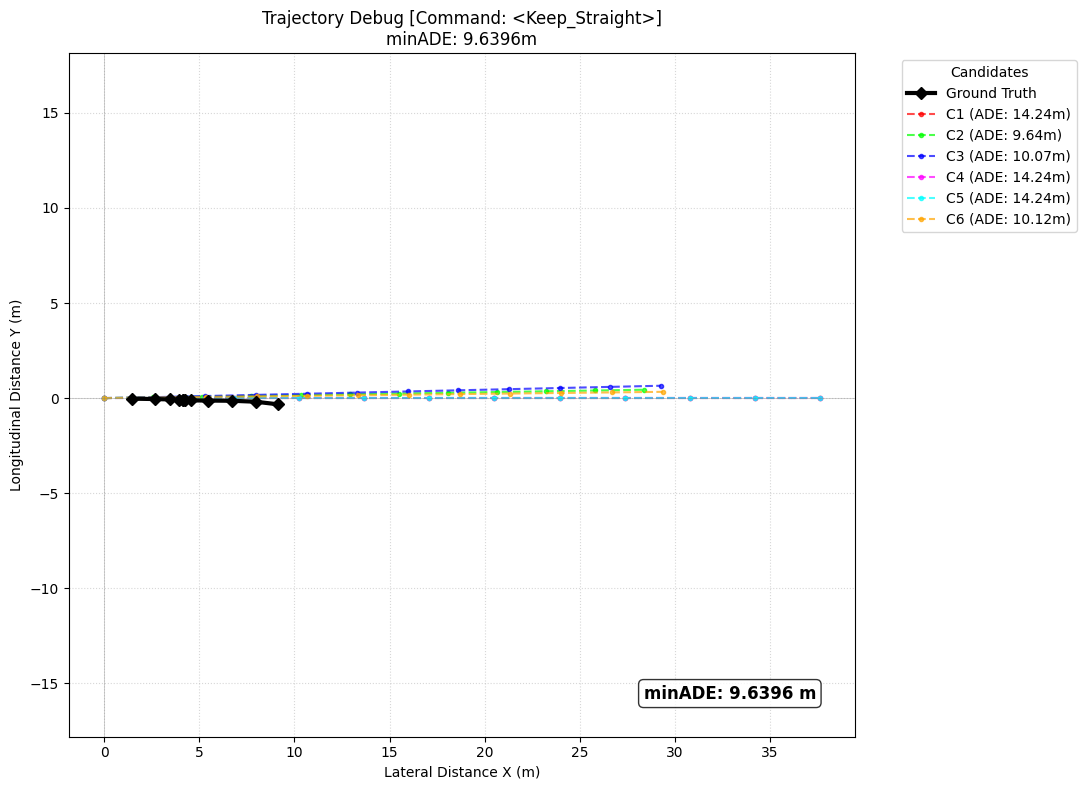

In [8]:
outputs, gt_wp, command, token = trainer.inference_once(temperature=0.7, top_p=0.8, sample_index=323)
print("Token:", token)
min_ade, best_trajectory = plot_debug_results(outputs, gt_wp, command)

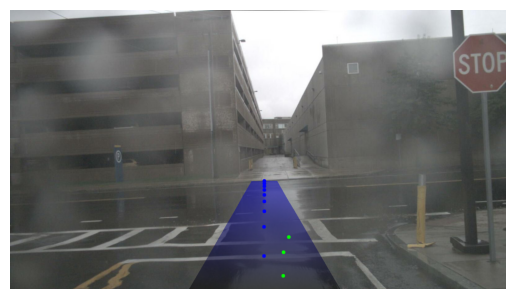

In [10]:
from utils.results_utils import project_wp_to_image

sample_token = token[0]
# plot_six_views_by_token(nusc, sample_token)

sample_record = nusc.get('sample', sample_token)
cam_front_token = sample_record['data']['CAM_FRONT']
cam_data = nusc.get('sample_data', cam_front_token)
image_path = os.path.join(nusc.dataroot, cam_data['filename'])
front_img = cv2.imread(image_path)
# vis_img = project_wp_to_image(nusc, sample_token, best_trajectory, front_img)
vis_img = project_wp_to_image(
    nusc, sample_token, best_trajectory, front_img,
    color_waypoints=(255, 0, 0),
    color_polygon=(200, 0, 0),
    plot_polygon=True
)
gt_pts_str = parse_string(gt_wp)
gt_x = gt_pts_str[:, 0]
gt_y = gt_pts_str[:, 1]
gt_pts = np.column_stack((gt_x, gt_y))
vis_img = project_wp_to_image(
    nusc, sample_token, gt_pts, vis_img,
    color_waypoints=(0, 255, 0),
    plot_polygon=False
)


# IMPORTANT: Convert BGR (OpenCV) to RGB (Matplotlib)
vis_img_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)

plt.imshow(vis_img_rgb)
plt.axis('off') # Hide coordinate axes
plt.show()